<a href="https://colab.research.google.com/github/alicexli/Lab-6/blob/main/AliceLi_datasci_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Install All Libraries**

In [5]:
!pip install google-play-scraper
!pip install vaderSentiment
!pip install pytrends
!pip install ruptures
!pip install wordcloud

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.5 MB/s eta 0:00:00


# **Apple App Store Scraping**

In [6]:
import requests
import pandas as pd
import time

apps = {
    'Facebook':  284882215,
    'Instagram': 389801252,
    'WhatsApp':  310633997,
    'Snapchat':  447188370,
    'TikTok':    835599320
}

all_reviews = []

for app_name, app_id in apps.items():
    print(f"Scraping {app_name}...")
    count = 0
    for page in range(1, 11):
        url = (f"https://itunes.apple.com/us/rss/customerreviews/"
               f"page={page}/id={app_id}/sortby=mostrecent/json")
        try:
            r = requests.get(
                url,
                headers={'User-Agent': 'Mozilla/5.0'},
                timeout=10
            )
            data = r.json()
            entries = data.get('feed', {}).get('entry', [])
            if not entries:
                break
            for entry in entries:
                if isinstance(entry, dict) and 'im:rating' in entry:
                    all_reviews.append({
                        'app':    app_name,
                        'text':   entry.get('content', {}).get('label', ''),
                        'rating': int(entry['im:rating']['label']),
                        'date':   entry.get('updated', {}).get('label', '')[:10],
                        'title':  entry.get('title',   {}).get('label', '')
                    })
                    count += 1
            time.sleep(1)
        except Exception as e:
            print(f"  Page {page} error: {e}")
            break
    print(f"  {app_name}: {count} reviews")

df_ios = pd.DataFrame(all_reviews)
df_ios['date'] = pd.to_datetime(df_ios['date'], errors='coerce')

print(f"\nTotal reviews: {len(df_ios)}")
print(f"\nYear distribution:")
print(df_ios['date'].dt.year.value_counts().sort_index())
print(f"\nSample:")
print(df_ios.head(3))

df_ios.to_csv('ios_reviews_raw.csv', index=False)
print("\n✅ App Store reviews saved!")

Scraping Facebook...
  Facebook: 500 reviews
Scraping Instagram...
  Instagram: 500 reviews
Scraping WhatsApp...
  WhatsApp: 500 reviews
Scraping Snapchat...
  Snapchat: 500 reviews
Scraping TikTok...
  TikTok: 500 reviews

Total reviews: 2500

Year distribution:
date
2026    2500
Name: count, dtype: int64

Sample:
        app                                               text  rating  \
0  Facebook                       This app is filled with bugs       1   
1  Facebook  Facebook allows for scam companies to rip peop...       1   
2  Facebook  Whatever Facebook has changed recently is not ...       1   

        date           title  
0 2026-03-17      Just buggy  
1 2026-03-17  Scam companies  
2 2026-03-17   Newest update  

✅ App Store reviews saved!


# **Guardian News API**

In [8]:
import requests
import pandas as pd
import time

API_KEY = '777f322c-34d8-4586-96c6-59bc27e31c5b'

queries = [
    'GDPR privacy law',
    'CCPA privacy law',
    'Facebook user data privacy',
    'data privacy app',
    'consumer data protection'
]

years        = range(2016, 2026)
all_articles = []

for year in years:
    print(f"\nFetching year {year}...")
    year_count = 0
    for query in queries:
        for page in range(1, 4):
            url    = 'https://content.guardianapis.com/search'
            params = {
                'q':           query,
                'from-date':   f'{year}-01-01',
                'to-date':     f'{year}-12-31',
                'order-by':    'relevance',
                'show-fields': 'bodyText,headline',
                'section':     'technology|business|us-news|world',
                'page-size':   10,
                'page':        page,
                'api-key':     API_KEY
            }
            try:
                r       = requests.get(url, params=params, timeout=10)
                data    = r.json()
                results = data['response']['results']
                if not results:
                    break
                for article in results:
                    fields   = article.get('fields', {})
                    headline = fields.get('headline', '')
                    body     = fields.get('bodyText', '')
                    combined = (headline + ' ' + body).lower()
                    if any(kw in combined for kw in
                           ['privacy', 'gdpr', 'ccpa', 'data protection',
                            'personal data', 'data breach', 'tracking']):
                        all_articles.append({
                            'date':     article.get(
                                'webPublicationDate','')[:10],
                            'headline': headline,
                            'text':     body,
                            'query':    query,
                            'section':  article.get('sectionName','')
                        })
                        year_count += 1
                time.sleep(0.3)
            except Exception as e:
                print(f"  Error: {e}")
                break
    print(f"  {year}: {year_count} relevant articles")

df_news = pd.DataFrame(all_articles).drop_duplicates(subset='headline')
df_news['date'] = pd.to_datetime(df_news['date'], errors='coerce')

print(f"\nTotal unique articles: {len(df_news)}")
print(f"\nYear distribution:")
print(df_news['date'].dt.year.value_counts().sort_index())

df_news.to_csv('guardian_news.csv', index=False)
print("\n✅ Guardian news saved!")

print("DATA COLLECTION SUMMARY")
print("="*55)
print(f"  Guardian articles : {len(df_news)}")
print(f"  App Store reviews : {len(df_ios)}")


Fetching year 2016...
  2016: 100 relevant articles

Fetching year 2017...
  2017: 60 relevant articles

Fetching year 2018...
  2018: 123 relevant articles

Fetching year 2019...
  2019: 102 relevant articles

Fetching year 2020...
  2020: 87 relevant articles

Fetching year 2021...
  2021: 63 relevant articles

Fetching year 2022...
  2022: 98 relevant articles

Fetching year 2023...
  2023: 99 relevant articles

Fetching year 2024...
  2024: 74 relevant articles

Fetching year 2025...
  2025: 74 relevant articles

Total unique articles: 524

Year distribution:
date
2016    56
2017    36
2018    74
2019    62
2020    55
2021    42
2022    52
2023    52
2024    44
2025    51
Name: count, dtype: int64

✅ Guardian news saved!
DATA COLLECTION SUMMARY
  Guardian articles : 524
  App Store reviews : 2500


# **Google Trends**

In [67]:
from pytrends.request import TrendReq
import pandas as pd
import time

pytrends = TrendReq(hl='en-US', tz=360)
timeframe = '2016-01-01 2025-12-31'

def get_trends(keywords):
    pytrends.build_payload(keywords, timeframe=timeframe)
    time.sleep(3)
    return pytrends.interest_over_time()

print("Fetching batch 1...")
df1 = get_trends(['GDPR', 'CCPA', 'data privacy', 'app privacy'])
time.sleep(5)

print("Fetching batch 2...")
df2 = get_trends(['delete Facebook', 'privacy settings',
                  'data regulation', 'data breach'])

# Merge
trends_df = pd.concat([df1, df2], axis=1)
trends_df = trends_df.loc[:, ~trends_df.columns.duplicated()]
trends_df.drop(columns=['isPartial'], inplace=True, errors='ignore')
trends_df.reset_index(inplace=True)

# Label periods
def label_period(date):
    if date >= pd.Timestamp('2020-01-01'):
        return 'post_ccpa'
    elif date >= pd.Timestamp('2018-05-25'):
        return 'post_gdpr'
    else:
        return 'pre_gdpr'

trends_df['period'] = trends_df['date'].apply(label_period)

trends_df.to_csv('google_trends.csv', index=False)

print(f"\nShape: {trends_df.shape}")
print(f"Date range: {trends_df['date'].min()} to {trends_df['date'].max()}")
print(f"\nPeriod distribution:")
print(trends_df['period'].value_counts())
print(f"\nSample:")
print(trends_df.head(3))

Fetching batch 1...
Fetching batch 2...

Shape: (120, 10)
Date range: 2016-01-01 00:00:00 to 2025-12-01 00:00:00

Period distribution:
period
post_ccpa    72
pre_gdpr     29
post_gdpr    19
Name: count, dtype: int64

Sample:
        date  GDPR  CCPA  data privacy  app privacy  delete Facebook  \
0 2016-01-01     0     0             1            0               50   
1 2016-02-01     0     0             1            0               46   
2 2016-03-01     0     0             1            1               46   

   privacy settings  data regulation  data breach    period  
0                 3                1            3  pre_gdpr  
1                 3                1            4  pre_gdpr  
2                 3                1            4  pre_gdpr  


# **Market Data**

In [3]:
import pandas as pd

# quarterly advertising revenue in millions USD
# enter from macrotrends - takes about 15 mins manually
ad_revenue_data = {
    'Meta': {
        # format: 'YYYY-QX': revenue_in_millions
        '2016-Q1': 5201, '2016-Q2': 6239,
        '2016-Q3': 6815, '2016-Q4': 8629,
        '2017-Q1': 7857, '2017-Q2': 9164,
        '2017-Q3': 10142,'2017-Q4': 12779,
        '2018-Q1': 11795,'2018-Q2': 13231,
        '2018-Q3': 13727,'2018-Q4': 16914,
        '2019-Q1': 14912,'2019-Q2': 16624,
        '2019-Q3': 17385,'2019-Q4': 20737,
        '2020-Q1': 17440,'2020-Q2': 18321,
        '2020-Q3': 21470,'2020-Q4': 27187,
        '2021-Q1': 25439,'2021-Q2': 28579,
        '2021-Q3': 28276,'2021-Q4': 32639,
        '2022-Q1': 27908,'2022-Q2': 28152,
        '2022-Q3': 27237,'2022-Q4': 31254,
        '2023-Q1': 28101,'2023-Q2': 31498,
        '2023-Q3': 34146,'2023-Q4': 38706,
        '2024-Q1': 40112,'2024-Q2': 36455,
        '2024-Q3': 39071,'2024-Q4': 40589,
        '2025-Q1': 48386,'2025-Q2': 42314,
        '2025-Q3': 47516,'2025-Q4': 51342,
        '2026-Q1': 59894,
    },
    'Snap': {
        '2016-Q2': 39,
        '2016-Q3': 72, '2016-Q4': 128,
        '2017-Q1': 166, '2017-Q2': 150,
        '2017-Q3': 182,'2017-Q4': 208,
        '2018-Q1': 286,'2018-Q2': 231,
        '2018-Q3': 262,'2018-Q4': 298,
        '2019-Q1': 390,'2019-Q2': 320,
        '2019-Q3': 388,'2019-Q4': 446,
        '2020-Q1': 561,'2020-Q2': 462,
        '2020-Q3': 454,'2020-Q4': 679,
        '2021-Q1': 911,'2021-Q2': 770,
        '2021-Q3': 982,'2021-Q4': 1067,
        '2022-Q1': 1298,'2022-Q2': 1063,
        '2022-Q3': 1111,'2022-Q4': 1128,
        '2023-Q1': 1300,'2023-Q2': 989,
        '2023-Q3': 1068,'2023-Q4': 1189,
        '2024-Q1': 1361,'2024-Q2': 1195,
        '2024-Q3': 1237,'2024-Q4': 1373,
        '2025-Q1': 1557,'2025-Q2': 1363,
        '2025-Q3': 1345,'2025-Q4': 1507,
        '2026-Q1': 1716,
    },
    'Alphabet': {
        '2016-Q1': 21329, '2016-Q2': 20257,
        '2016-Q3': 21500, '2016-Q4': 22451,
        '2017-Q1': 26064, '2017-Q2': 24750,
        '2017-Q3': 26010,'2017-Q4': 27772,
        '2018-Q1': 32323,'2018-Q2': 31146,
        '2018-Q3': 32657,'2018-Q4': 33740,
        '2019-Q1': 39276,'2019-Q2': 36339,
        '2019-Q3': 38944,'2019-Q4': 40499,
        '2020-Q1': 46075,'2020-Q2': 41159,
        '2020-Q3': 38297,'2020-Q4': 46173,
        '2021-Q1': 56898,'2021-Q2': 55314,
        '2021-Q3': 61880,'2021-Q4': 65118,
        '2022-Q1': 75325,'2022-Q2': 68011,
        '2022-Q3': 69685,'2022-Q4': 69092,
        '2023-Q1': 76048,'2023-Q2': 69787,
        '2023-Q3': 76404,'2023-Q4': 76693,
        '2024-Q1': 86310,'2024-Q2': 80539,
        '2024-Q3': 84742,'2024-Q4': 88268,
        '2025-Q1': 96469,'2025-Q2': 90234,
        '2025-Q3': 96428,'2025-Q4': 102346,
        '2026-Q1': 113828,
    },
}

# convert to dataframe
rows = []
for company, quarters in ad_revenue_data.items():
    for quarter, revenue in quarters.items():
        year = int(quarter.split('-Q')[0])
        q    = int(quarter.split('-Q')[1])
        # convert quarter to approximate date
        month = {1:1, 2:4, 3:7, 4:10}[q]
        rows.append({
            'company':      company,
            'quarter':      quarter,
            'year':         year,
            'q':            q,
            'date':         pd.Timestamp(year=year,
                                         month=month, day=1),
            'ad_revenue_m': revenue
        })

df_revenue = pd.DataFrame(rows)
df_revenue = df_revenue.sort_values(['company','date'])

print(f"Total records: {len(df_revenue)}")
print(f"\nRecords by company:")
print(df_revenue['company'].value_counts())
print(f"\nSample:")
print(df_revenue.head(8))

df_revenue.to_csv('ad_revenue.csv', index=False)
print("\n✅ Ad revenue saved!")

Total records: 122

Records by company:
company
Alphabet    41
Meta        41
Snap        40
Name: count, dtype: int64

Sample:
     company  quarter  year  q       date  ad_revenue_m
81  Alphabet  2016-Q1  2016  1 2016-01-01         21329
82  Alphabet  2016-Q2  2016  2 2016-04-01         20257
83  Alphabet  2016-Q3  2016  3 2016-07-01         21500
84  Alphabet  2016-Q4  2016  4 2016-10-01         22451
85  Alphabet  2017-Q1  2017  1 2017-01-01         26064
86  Alphabet  2017-Q2  2017  2 2017-04-01         24750
87  Alphabet  2017-Q3  2017  3 2017-07-01         26010
88  Alphabet  2017-Q4  2017  4 2017-10-01         27772

✅ Ad revenue saved!


In [10]:
import yfinance as yf
import pandas as pd

companies = {
    'Meta':     'META',
    'Snap':     'SNAP',
    'Alphabet': 'GOOGL'
}

all_prices = []

for company, ticker in companies.items():
    print(f"Fetching {company} ({ticker})...")
    try:
        stock = yf.Ticker(ticker)
        hist  = stock.history(start='2016-01-01',
                              end='2025-12-31',
                              interval='1mo')  # monthly prices
        hist  = hist.reset_index()
        hist['company'] = company
        hist['ticker']  = ticker
        all_prices.append(hist[['Date','Close',
                                 'Volume','company','ticker']])
        print(f"  {company}: {len(hist)} months")
    except Exception as e:
        print(f"  Error: {e}")

df_stocks = pd.concat(all_prices, ignore_index=True)
df_stocks.columns = ['date','price','volume','company','ticker']
df_stocks['date'] = pd.to_datetime(df_stocks['date'])

print(f"\nTotal records: {len(df_stocks)}")
print(f"\nDate range: {df_stocks['date'].min()} to {df_stocks['date'].max()}")
print(f"\nRecords by company:")
print(df_stocks['company'].value_counts())

df_stocks.to_csv('stock_prices.csv', index=False)
print("\n✅ Stock prices saved!")

Fetching Meta (META)...
  Meta: 120 months
Fetching Snap (SNAP)...
  Snap: 106 months
Fetching Alphabet (GOOGL)...
  Alphabet: 120 months

Total records: 346

Date range: 2016-01-01 00:00:00-05:00 to 2025-12-01 00:00:00-05:00

Records by company:
company
Meta        120
Alphabet    120
Snap        106
Name: count, dtype: int64

✅ Stock prices saved!


# **checks and stuff**

In [15]:
import pandas as pd
import numpy as np

# load
df_news    = pd.read_csv('guardian_news.csv')
df_trends  = pd.read_csv('google_trends.csv')
df_stocks  = pd.read_csv('stock_prices.csv')
df_revenue = pd.read_csv('ad_revenue.csv')

# dates
df_news['date']    = pd.to_datetime(df_news['date'],    errors='coerce')
df_trends['date']  = pd.to_datetime(df_trends['date'],  errors='coerce')
df_stocks['date']  = pd.to_datetime(df_stocks['date'],  utc=True).dt.tz_localize(None)
df_revenue['date'] = pd.to_datetime(df_revenue['date'], errors='coerce')

# drop premature 2026 ad revenue
df_revenue = df_revenue[df_revenue['year'] < 2026]

# add period labels to news
def label_period(date):
    if pd.isnull(date):                          return 'unknown'
    if date >= pd.Timestamp('2020-01-01'):        return 'post_ccpa'
    elif date >= pd.Timestamp('2018-05-25'):      return 'post_gdpr'
    else:                                         return 'pre_gdpr'

df_news['period'] = df_news['date'].apply(label_period)

# add GDPR marker to stocks and revenue
GDPR_DATE = pd.Timestamp('2018-05-25')
df_stocks['post_gdpr']  = (df_stocks['date']  >= GDPR_DATE).astype(int)
df_revenue['post_gdpr'] = (df_revenue['date'] >= GDPR_DATE).astype(int)

print("✅ All data loaded and cleaned")
print(f"  Guardian articles : {len(df_news)}")
print(f"  Trends datapoints : {len(df_trends)}")
print(f"  Stock records     : {len(df_stocks)}")
print(f"  Revenue quarters  : {len(df_revenue)}")

✅ All data loaded and cleaned
  Guardian articles : 524
  Trends datapoints : 120
  Stock records     : 346
  Revenue quarters  : 119


# **Sentiment Analysis**

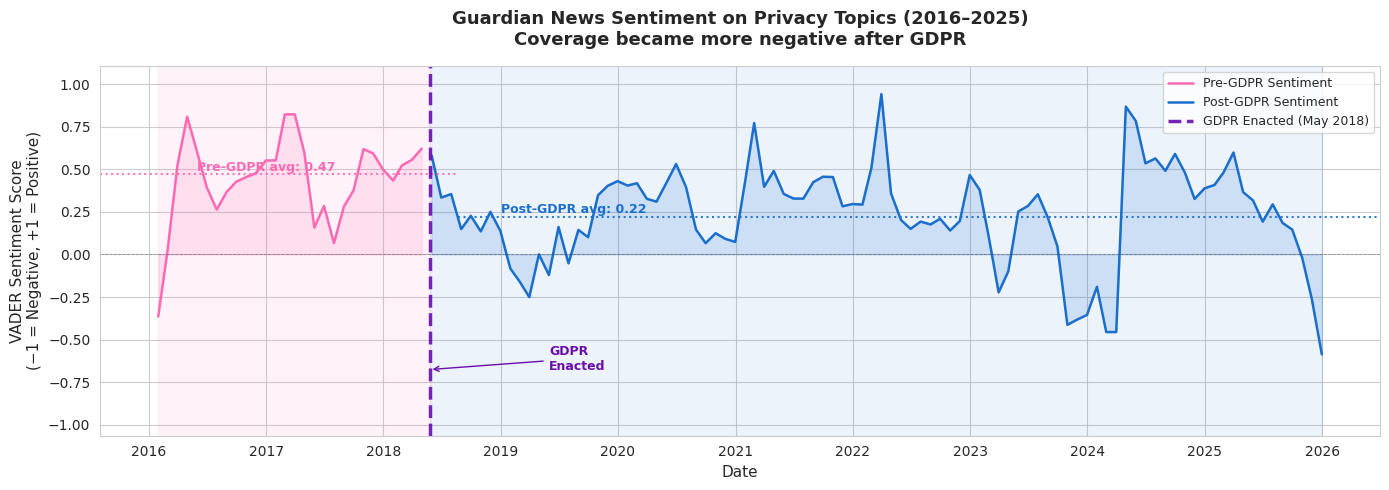

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# monthly average sentiment
monthly_sent = (
    df_news.set_index('date')
    .resample('ME')['sentiment']
    .mean()
    .reset_index()
)
monthly_sent.columns = ['date', 'sentiment']

# rolling average
monthly_sent['rolling'] = (
    monthly_sent['sentiment']
    .rolling(3, center=True, min_periods=1)
    .mean()
)

GDPR_COLOR = '#6a0dad'
PRE_COLOR  = '#ff69b4'   # red
POST_COLOR = '#1a6fcc'   # blue

pre_mean  = df_news[df_news['period']=='pre_gdpr']['sentiment'].mean()
post_mean = df_news[df_news['period']=='post_gdpr']['sentiment'].mean()

gdpr_date = pd.Timestamp('2018-05-25')

# split rolling average into pre and post
pre_data  = monthly_sent[monthly_sent['date'] <= gdpr_date]
post_data = monthly_sent[monthly_sent['date'] >= gdpr_date]

fig, ax = plt.subplots(figsize=(14, 5))

# shaded regions
ax.axvspan(monthly_sent['date'].min(), gdpr_date,
           alpha=0.08, color=PRE_COLOR)
ax.axvspan(gdpr_date, monthly_sent['date'].max(),
           alpha=0.08, color=POST_COLOR)

# rolling average lines — red pre, blue post
ax.plot(pre_data['date'], pre_data['rolling'],
        color=PRE_COLOR, linewidth=1.8,
        label='Pre-GDPR Sentiment')
ax.fill_between(pre_data['date'], pre_data['rolling'],
                alpha=0.15, color=PRE_COLOR)

ax.plot(post_data['date'], post_data['rolling'],
        color=POST_COLOR, linewidth=1.8,
        label='Post-GDPR Sentiment')
ax.fill_between(post_data['date'], post_data['rolling'],
                alpha=0.15, color=POST_COLOR)

# period average dotted lines
ax.axhline(pre_mean,
           xmin=0, xmax=0.28,
           color=PRE_COLOR, linewidth=1.5,
           linestyle=':', alpha=0.9)
ax.axhline(post_mean,
           xmin=0.28, xmax=1.0,
           color=POST_COLOR, linewidth=1.5,
           linestyle=':', alpha=0.9)

# period average labels
ax.text(pd.Timestamp('2016-06-01'), pre_mean + 0.02,
        f'Pre-GDPR avg: {pre_mean:.2f}',
        fontsize=9, color=PRE_COLOR, fontweight='bold')
ax.text(pd.Timestamp('2019-01-01'), post_mean + 0.02,
        f'Post-GDPR avg: {post_mean:.2f}',
        fontsize=9, color=POST_COLOR, fontweight='bold')

# GDPR vertical line
ax.axvline(gdpr_date, color=GDPR_COLOR, linewidth=2.5,
           linestyle='--', alpha=0.9,
           label='GDPR Enacted (May 2018)')

# GDPR annotation
y_min = monthly_sent['sentiment'].min()
y_max = monthly_sent['sentiment'].max()

ax.annotate('GDPR\nEnacted',
            xy=(gdpr_date,
                y_min + (y_max - y_min) * 0.15),
            xytext=(pd.Timestamp('2019-06-01'),
                    y_min + (y_max - y_min) * 0.15),
            fontsize=9, color=GDPR_COLOR,
            fontweight='bold',
            arrowprops=dict(arrowstyle='->',
                            color=GDPR_COLOR))

# zero reference line
ax.axhline(0, color='black', linewidth=0.6,
           linestyle='--', alpha=0.3)

ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('VADER Sentiment Score\n(−1 = Negative, +1 = Positive)',
              fontsize=11)
ax.set_title('Guardian News Sentiment on Privacy Topics (2016–2025)\n'
             'Coverage became more negative after GDPR',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=9, loc='upper right')
ax.set_ylim(y_min - 0.1, y_max + 0.15)

plt.tight_layout()
plt.savefig('chart1_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()

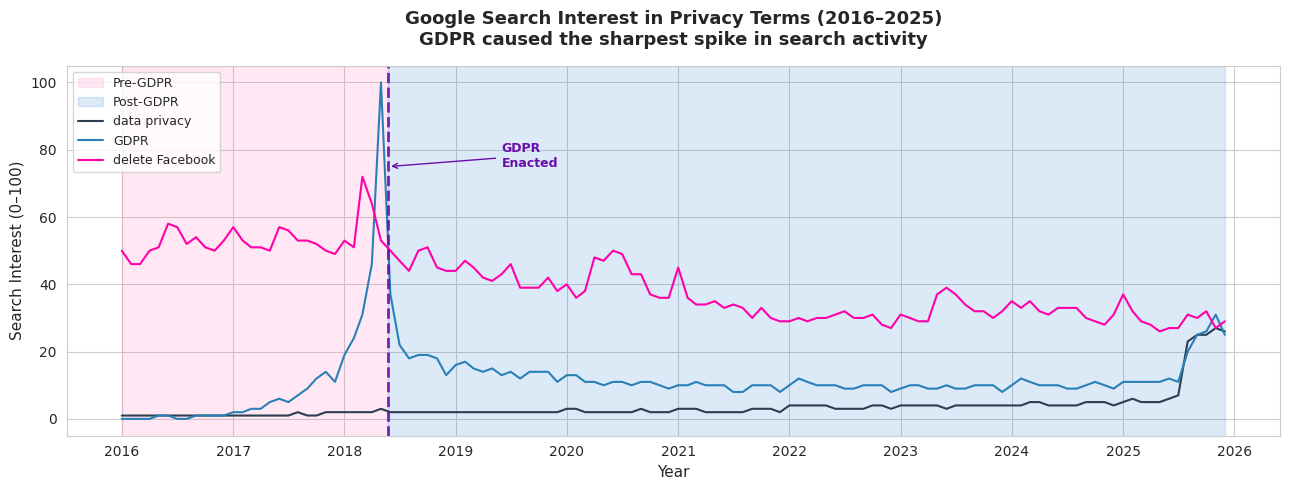

In [70]:
fig, ax = plt.subplots(figsize=(13, 5))

GDPR_COLOR = '#6a0dad'
gdpr_date  = pd.Timestamp('2018-05-25')

# shaded regions
ax.axvspan(trends_df['date'].min(), gdpr_date,
           alpha=0.15, color='#ff69b4',
           label='Pre-GDPR')
ax.axvspan(gdpr_date, trends_df['date'].max(),
           alpha=0.15, color='#1a6fcc',
           label='Post-GDPR')

# 3 terms
ax.plot(trends_df['date'], trends_df['data privacy'],
        color='#2c3e50', linewidth=1.5,
        label='data privacy')
ax.plot(trends_df['date'], trends_df['GDPR'],
        color='#2980b9', linewidth=1.5,
        label='GDPR')
ax.plot(trends_df['date'], trends_df['delete Facebook'],
        color='#ff00aa', linewidth=1.5,
        label='delete Facebook')

# GDPR vertical line
ax.axvline(gdpr_date, color=GDPR_COLOR,
           linewidth=2, linestyle='--',
           alpha=0.9)

# GDPR annotation
ymax = trends_df[['data privacy','GDPR',
                  'delete Facebook']].max().max()
ax.annotate('GDPR\nEnacted',
            xy=(gdpr_date, ymax * 0.75),
            xytext=(pd.Timestamp('2019-06-01'), ymax * 0.75),
            fontsize=9, color=GDPR_COLOR,
            fontweight='bold',
            arrowprops=dict(arrowstyle='->',
                            color=GDPR_COLOR))

ax.set_title('Google Search Interest in Privacy Terms (2016–2025)\n'
             'GDPR caused the sharpest spike in search activity',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Search Interest (0–100)', fontsize=11)
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig('chart2_trends.png', dpi=150, bbox_inches='tight')
plt.show()

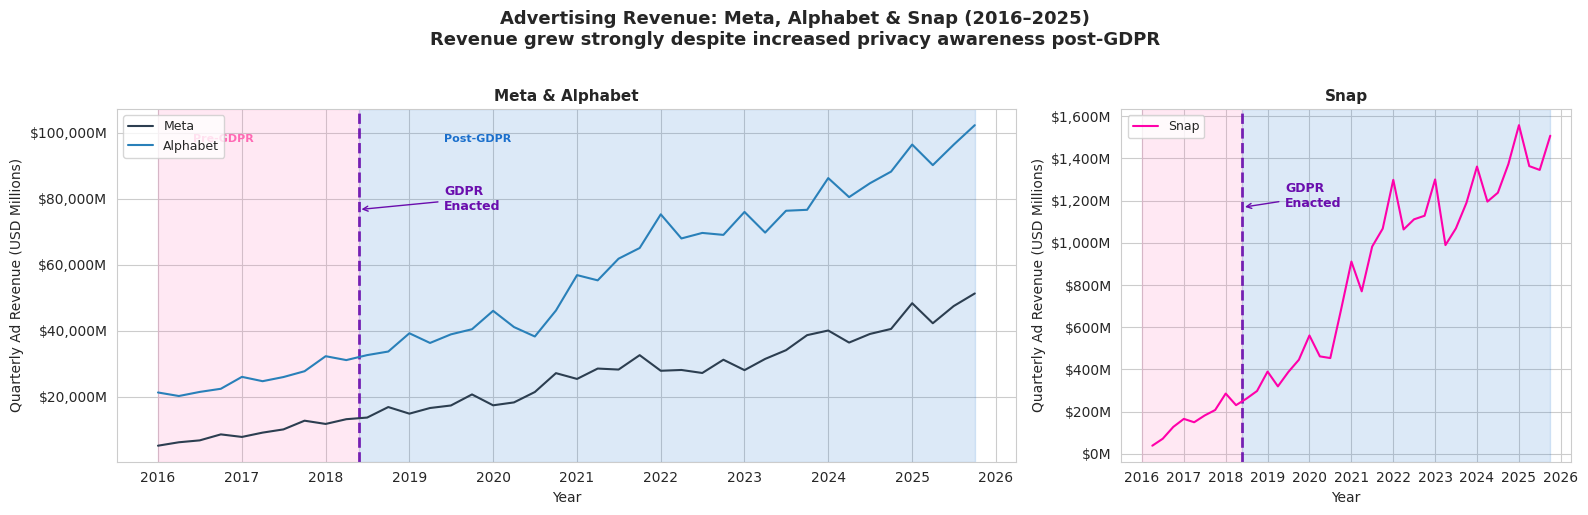

In [44]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

GDPR_COLOR = '#6a0dad'
gdpr_date  = pd.Timestamp('2018-05-25')

company_colors = {
    'Meta':     '#2c3e50',
    'Alphabet': '#2980b9',
    'Snap':     '#ff00aa'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5),
                                gridspec_kw={'width_ratios': [2, 1]})

# ── LEFT PANEL — Meta and Alphabet ──────────────────────────────
for ax in [ax1, ax2]:
    ax.axvspan(df_revenue['date'].min(), gdpr_date,
               alpha=0.15, color='#ff69b4')
    ax.axvspan(gdpr_date, df_revenue['date'].max(),
               alpha=0.15, color='#1a6fcc')
    ax.axvline(gdpr_date, color=GDPR_COLOR,
               linewidth=2, linestyle='--', alpha=0.9)

for company in ['Meta', 'Alphabet']:
    data = df_revenue[
        df_revenue['company']==company].sort_values('date')
    ax1.plot(data['date'], data['ad_revenue_m'],
             color=company_colors[company],
             linewidth=1.5, label=company)

ymax1 = df_revenue[df_revenue['company'].isin(
    ['Meta','Alphabet'])]['ad_revenue_m'].max()

ax1.annotate('GDPR\nEnacted',
             xy=(gdpr_date, ymax1 * 0.75),
             xytext=(pd.Timestamp('2019-06-01'), ymax1 * 0.75),
             fontsize=9, color=GDPR_COLOR, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=GDPR_COLOR))

ax1.set_title('Meta & Alphabet', fontweight='bold', fontsize=11)
ax1.set_xlabel('Year', fontsize=10)
ax1.set_ylabel('Quarterly Ad Revenue (USD Millions)', fontsize=10)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
ax1.legend(loc='upper left', fontsize=9)

# add pre/post labels to left panel only
ax1.text(pd.Timestamp('2016-06-01'), ymax1 * 0.95,
         'Pre-GDPR', fontsize=8,
         color='#ff69b4', fontweight='bold')
ax1.text(pd.Timestamp('2019-06-01'), ymax1 * 0.95,
         'Post-GDPR', fontsize=8,
         color='#1a6fcc', fontweight='bold')

# ── RIGHT PANEL — Snap only ──────────────────────────────────────
snap_data = df_revenue[
    df_revenue['company']=='Snap'].sort_values('date')
ax2.plot(snap_data['date'], snap_data['ad_revenue_m'],
         color=company_colors['Snap'],
         linewidth=1.5, label='Snap')

ymax2 = snap_data['ad_revenue_m'].max()
ax2.annotate('GDPR\nEnacted',
             xy=(gdpr_date, ymax2 * 0.75),
             xytext=(pd.Timestamp('2019-06-01'), ymax2 * 0.75),
             fontsize=9, color=GDPR_COLOR, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=GDPR_COLOR))

ax2.set_title('Snap', fontweight='bold', fontsize=11)
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylabel('Quarterly Ad Revenue (USD Millions)', fontsize=10)
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}M'))
ax2.legend(loc='upper left', fontsize=9)

plt.suptitle(
    'Advertising Revenue: Meta, Alphabet & Snap (2016–2025)\n'
    'Revenue grew strongly despite increased privacy awareness post-GDPR',
    fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('chart3_ad_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

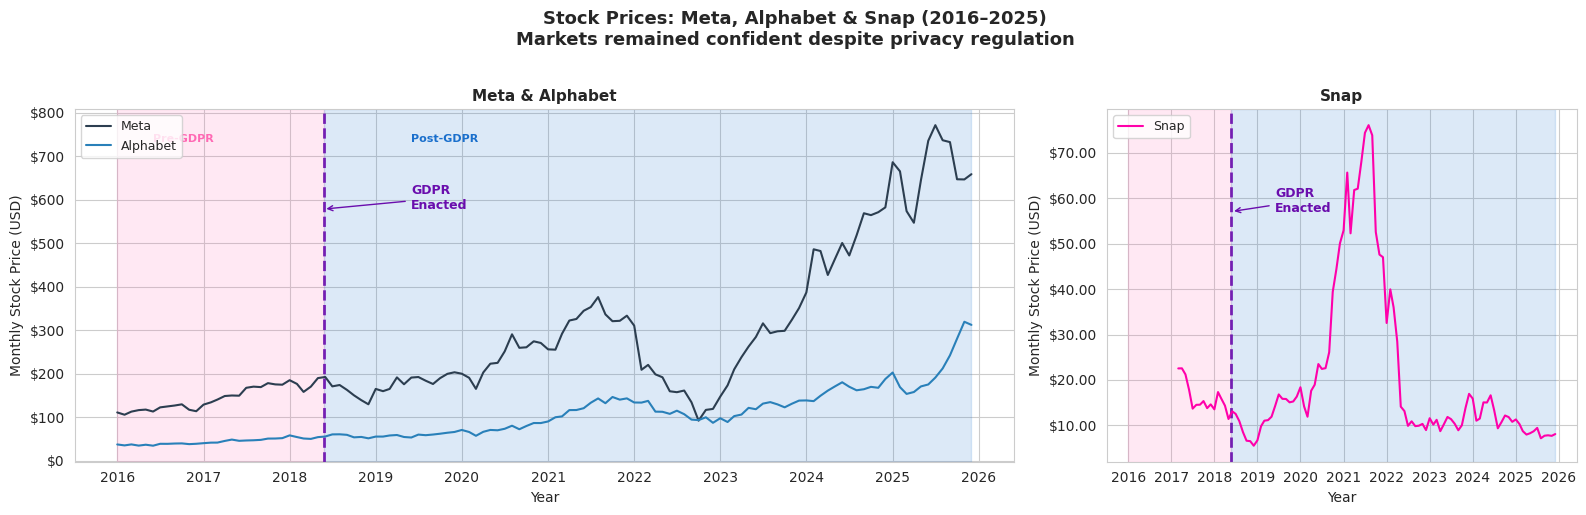

In [74]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

GDPR_COLOR = '#6a0dad'
gdpr_date  = pd.Timestamp('2018-05-25')

company_colors = {
    'Meta':     '#2c3e50',
    'Alphabet': '#2980b9',
    'Snap':     '#ff00aa'
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5),
                                gridspec_kw={'width_ratios': [2, 1]})

# ── LEFT PANEL — Meta and Alphabet ──────────────────────────────
for ax in [ax1, ax2]:
    ax.axvspan(df_stocks['date'].min(), gdpr_date,
               alpha=0.15, color='#ff69b4')
    ax.axvspan(gdpr_date, df_stocks['date'].max(),
               alpha=0.15, color='#1a6fcc')
    ax.axvline(gdpr_date, color=GDPR_COLOR,
               linewidth=2, linestyle='--', alpha=0.9)

for company in ['Meta', 'Alphabet']:
    data = df_stocks[
        df_stocks['company']==company].sort_values('date')
    ax1.plot(data['date'], data['price'],
             color=company_colors[company],
             linewidth=1.5, label=company)

ymax1 = df_stocks[df_stocks['company'].isin(
    ['Meta','Alphabet'])]['price'].max()

ax1.annotate('GDPR\nEnacted',
             xy=(gdpr_date, ymax1 * 0.75),
             xytext=(pd.Timestamp('2019-06-01'), ymax1 * 0.75),
             fontsize=9, color=GDPR_COLOR, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=GDPR_COLOR))

ax1.text(pd.Timestamp('2016-06-01'), ymax1 * 0.95,
         'Pre-GDPR', fontsize=8,
         color='#ff69b4', fontweight='bold')
ax1.text(pd.Timestamp('2019-06-01'), ymax1 * 0.95,
         'Post-GDPR', fontsize=8,
         color='#1a6fcc', fontweight='bold')

ax1.set_title('Meta & Alphabet', fontweight='bold', fontsize=11)
ax1.set_xlabel('Year', fontsize=10)
ax1.set_ylabel('Monthly Stock Price (USD)', fontsize=10)
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.legend(loc='upper left', fontsize=9)

# ── RIGHT PANEL — Snap ──────────────────────────────────────────
snap_data = df_stocks[
    df_stocks['company']=='Snap'].sort_values('date')
ax2.plot(snap_data['date'], snap_data['price'],
         color=company_colors['Snap'],
         linewidth=1.5, label='Snap')

ymax2 = snap_data['price'].max()
ax2.annotate('GDPR\nEnacted',
             xy=(gdpr_date, ymax2 * 0.75),
             xytext=(pd.Timestamp('2019-06-01'), ymax2 * 0.75),
             fontsize=9, color=GDPR_COLOR, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color=GDPR_COLOR))

ax2.set_title('Snap', fontweight='bold', fontsize=11)
ax2.set_xlabel('Year', fontsize=10)
ax2.set_ylabel('Monthly Stock Price (USD)', fontsize=10)
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.2f}'))
ax2.legend(loc='upper left', fontsize=9)

plt.suptitle(
    'Stock Prices: Meta, Alphabet & Snap (2016–2025)\n'
    'Markets remained confident despite privacy regulation',
    fontsize=13, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('chart4_stocks.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
from scipy import stats

pre  = df_news[df_news['period']=='pre_gdpr']['sentiment']
post = df_news[df_news['period']=='post_gdpr']['sentiment']

t, p = stats.ttest_ind(pre, post)
print(f"Pre-GDPR mean:  {pre.mean():.4f}")
print(f"Post-GDPR mean: {post.mean():.4f}")
print(f"T-statistic:    {t:.3f}")
print(f"P-value:        {p:.4f}")
print("SIGNIFICANT" if p < 0.05 else "NOT SIGNIFICANT") #Guardian news sentiment dropped significantly after GDPR enactment (t-test, p=0.01)

Pre-GDPR mean:  0.4717
Post-GDPR mean: 0.2212
T-statistic:    2.573
P-value:        0.0107
SIGNIFICANT


T-TEST RESULTS
Pre-GDPR mean:        0.4717  (n=119)
Post-GDPR mean:       0.2212  (n=109)
Post-CCPA mean:       0.1949  (n=296)

Pre vs Post-GDPR:  t=2.573, p=0.0107 ✅ SIGNIFICANT
Pre vs Post-CCPA:  t=3.296, p=0.0011 ✅ SIGNIFICANT
GDPR vs CCPA:      t=0.295, p=0.7684 ❌ not significant


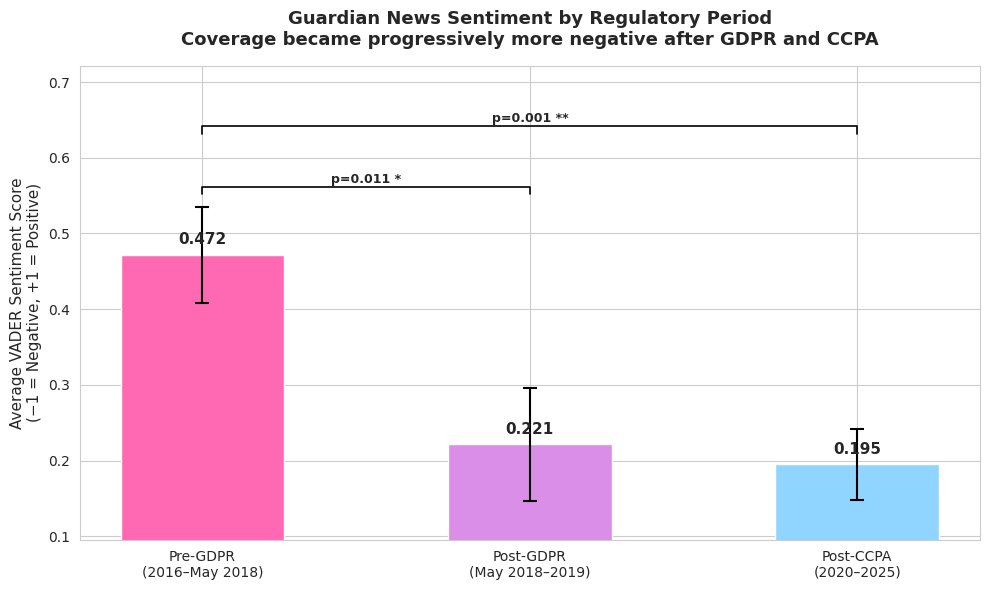

In [83]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

pre       = df_news[df_news['period']=='pre_gdpr']['sentiment']
post_gdpr = df_news[df_news['period']=='post_gdpr']['sentiment']
post_ccpa = df_news[df_news['period']=='post_ccpa']['sentiment']

# t-tests
t1, p1 = stats.ttest_ind(pre, post_gdpr)
t2, p2 = stats.ttest_ind(pre, post_ccpa)
t3, p3 = stats.ttest_ind(post_gdpr, post_ccpa)

print("=" * 45)
print("T-TEST RESULTS")
print("=" * 45)
print(f"Pre-GDPR mean:        {pre.mean():.4f}  (n={len(pre)})")
print(f"Post-GDPR mean:       {post_gdpr.mean():.4f}  (n={len(post_gdpr)})")
print(f"Post-CCPA mean:       {post_ccpa.mean():.4f}  (n={len(post_ccpa)})")
print()
print(f"Pre vs Post-GDPR:  t={t1:.3f}, p={p1:.4f}",
      "✅ SIGNIFICANT" if p1 < 0.05 else "❌ not significant")
print(f"Pre vs Post-CCPA:  t={t2:.3f}, p={p2:.4f}",
      "✅ SIGNIFICANT" if p2 < 0.05 else "❌ not significant")
print(f"GDPR vs CCPA:      t={t3:.3f}, p={p3:.4f}",
      "✅ SIGNIFICANT" if p3 < 0.05 else "❌ not significant")

# ── BAR CHART ────────────────────────────────────────────────────
periods = ['Pre-GDPR\n(2016–May 2018)',
           'Post-GDPR\n(May 2018–2019)',
           'Post-CCPA\n(2020–2025)']
means   = [pre.mean(), post_gdpr.mean(), post_ccpa.mean()]
errors  = [pre.sem(),  post_gdpr.sem(),  post_ccpa.sem()]
colors  = ['#ff69b4', '#DA8EE7', '#90D5FF']

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(periods, means,
              color=colors, edgecolor='white',
              width=0.5, yerr=errors,
              capsize=5,
              error_kw=dict(elinewidth=1.5,
                            ecolor='black',
                            capthick=1.5))

# value labels on bars
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f'{val:.3f}',
            ha='center', va='bottom',
            fontsize=11, fontweight='bold')

# significance brackets
def draw_bracket(ax, x1, x2, y, p_val):
    sig = ('***' if p_val < 0.001 else
           '**'  if p_val < 0.01  else
           '*'   if p_val < 0.05  else 'n.s.')
    ax.plot([x1, x1, x2, x2],
            [y, y+0.01, y+0.01, y],
            color='black', linewidth=1.2)
    ax.text((x1+x2)/2, y+0.015,
            f'p={p_val:.3f} {sig}',
            ha='center', fontsize=9,
            fontweight='bold')

y_bracket = max(means) + 0.08
draw_bracket(ax, 0, 1, y_bracket,        p1)
draw_bracket(ax, 0, 2, y_bracket + 0.08, p2)

ax.axhline(0, color='black', linewidth=0.6,
           linestyle='--', alpha=0.3)

ax.set_ylabel('Average VADER Sentiment Score\n(−1 = Negative, +1 = Positive)',
              fontsize=11)
ax.set_title('Guardian News Sentiment by Regulatory Period\n'
             'Coverage became progressively more negative after GDPR and CCPA',
             fontsize=13, fontweight='bold', pad=15)

y_min = min(means) - 0.1
y_max = max(means) + 0.25
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('chart_ttest_bars.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
gdpr_date = pd.Timestamp('2018-05-25')

pre  = trends_df[trends_df['date'] < gdpr_date]
post = trends_df[trends_df['date'] >= gdpr_date]

terms = ['data privacy', 'GDPR', 'delete Facebook']

print("Google Trends — Pre vs Post GDPR averages")
print("="*45)
for term in terms:
    pre_mean  = pre[term].mean()
    post_mean = post[term].mean()
    change    = ((post_mean - pre_mean) / pre_mean) * 100
    print(f"{term:20s}  pre={pre_mean:.1f}  "
          f"post={post_mean:.1f}  "
          f"change={change:+.1f}%")

Google Trends — Pre vs Post GDPR averages
data privacy          pre=1.3  post=4.5  change=+239.6%
GDPR                  pre=10.5  post=12.3  change=+17.1%
delete Facebook       pre=53.2  post=35.5  change=-33.3%


In [40]:
pre_rev  = df_revenue[df_revenue['date'] < gdpr_date]
post_rev = df_revenue[df_revenue['date'] >= gdpr_date]

print("\nAd Revenue — Pre vs Post GDPR quarterly average (millions)")
print("="*45)
for company in ['Meta', 'Alphabet', 'Snap']:
    pre_mean  = pre_rev[pre_rev['company']==company]['ad_revenue_m'].mean()
    post_mean = post_rev[post_rev['company']==company]['ad_revenue_m'].mean()
    change    = ((post_mean - pre_mean) / pre_mean) * 100
    print(f"{company:10s}  pre=${pre_mean:,.0f}M  "
          f"post=${post_mean:,.0f}M  "
          f"change={change:+.1f}%")


Ad Revenue — Pre vs Post GDPR quarterly average (millions)
Meta        pre=$9,185M  post=$29,748M  change=+223.9%
Alphabet    pre=$25,360M  post=$64,625M  change=+154.8%
Snap        pre=$162M  post=$936M  change=+476.1%


In [41]:
pre_stock  = df_stocks[df_stocks['date'] < gdpr_date]
post_stock = df_stocks[df_stocks['date'] >= gdpr_date]

print("\nStock Price — Pre vs Post GDPR monthly average")
print("="*45)
for company in ['Meta', 'Alphabet', 'Snap']:
    pre_mean  = pre_stock[pre_stock['company']==company]['price'].mean()
    post_stock_mean = post_stock[post_stock['company']==company]['price'].mean()
    change    = ((post_stock_mean - pre_mean) / pre_mean) * 100
    print(f"{company:10s}  pre=${pre_mean:,.0f}  "
          f"post=${post_stock_mean:,.0f}  "
          f"change={change:+.1f}%")


Stock Price — Pre vs Post GDPR monthly average
Meta        pre=$144  post=$322  change=+123.1%
Alphabet    pre=$44  post=$119  change=+167.5%
Snap        pre=$16  post=$21  change=+27.7%


# **TF-IDF**

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gdpr_date = pd.Timestamp('2018-05-25')

# split headlines into pre and post
pre_docs  = df_news[df_news['date'] < gdpr_date
                    ]['headline'].fillna('').tolist()
post_docs = df_news[df_news['date'] >= gdpr_date
                    ]['headline'].fillna('').tolist()

print(f"Pre-GDPR headlines:  {len(pre_docs)}")
print(f"Post-GDPR headlines: {len(post_docs)}")

all_docs = pre_docs + post_docs

tfidf = TfidfVectorizer(
    max_features  = 200,
    stop_words    = 'english',
    min_df        = 2,
    ngram_range   = (1, 2)   # include two-word phrases
)
tfidf_matrix = tfidf.fit_transform(all_docs)
vocab        = tfidf.get_feature_names_out()

pre_matrix  = tfidf_matrix[:len(pre_docs)]
post_matrix = tfidf_matrix[len(pre_docs):]

pre_scores  = np.array(pre_matrix.mean(axis=0)).flatten()
post_scores = np.array(post_matrix.mean(axis=0)).flatten()

shift_df = pd.DataFrame({
    'term':       vocab,
    'pre_score':  pre_scores,
    'post_score': post_scores
})
shift_df['shift'] = shift_df['post_score'] - shift_df['pre_score']

top_increased = shift_df.nlargest(12,  'shift')
top_decreased = shift_df.nsmallest(12, 'shift')

print("\nTop terms INCREASED after GDPR:")
print(top_increased[['term','shift']].to_string(index=False))
print("\nTop terms DECREASED after GDPR:")
print(top_decreased[['term','shift']].to_string(index=False))

Pre-GDPR headlines:  119
Post-GDPR headlines: 405

Top terms INCREASED after GDPR:
     term    shift
   tiktok 0.035685
    apple 0.032696
     meta 0.023317
       uk 0.017791
    fined 0.016657
       ai 0.016206
 concerns 0.015840
    china 0.012992
australia 0.012836
    right 0.011239
      ban 0.010663
   breach 0.010533

Top terms DECREASED after GDPR:
           term     shift
       facebook -0.048495
       whatsapp -0.045677
           data -0.044507
           gdpr -0.035725
     protection -0.021449
      user data -0.020746
        sharing -0.019377
   sharing user -0.017753
data protection -0.017655
  data facebook -0.017350
   data sharing -0.015851
          warns -0.015577


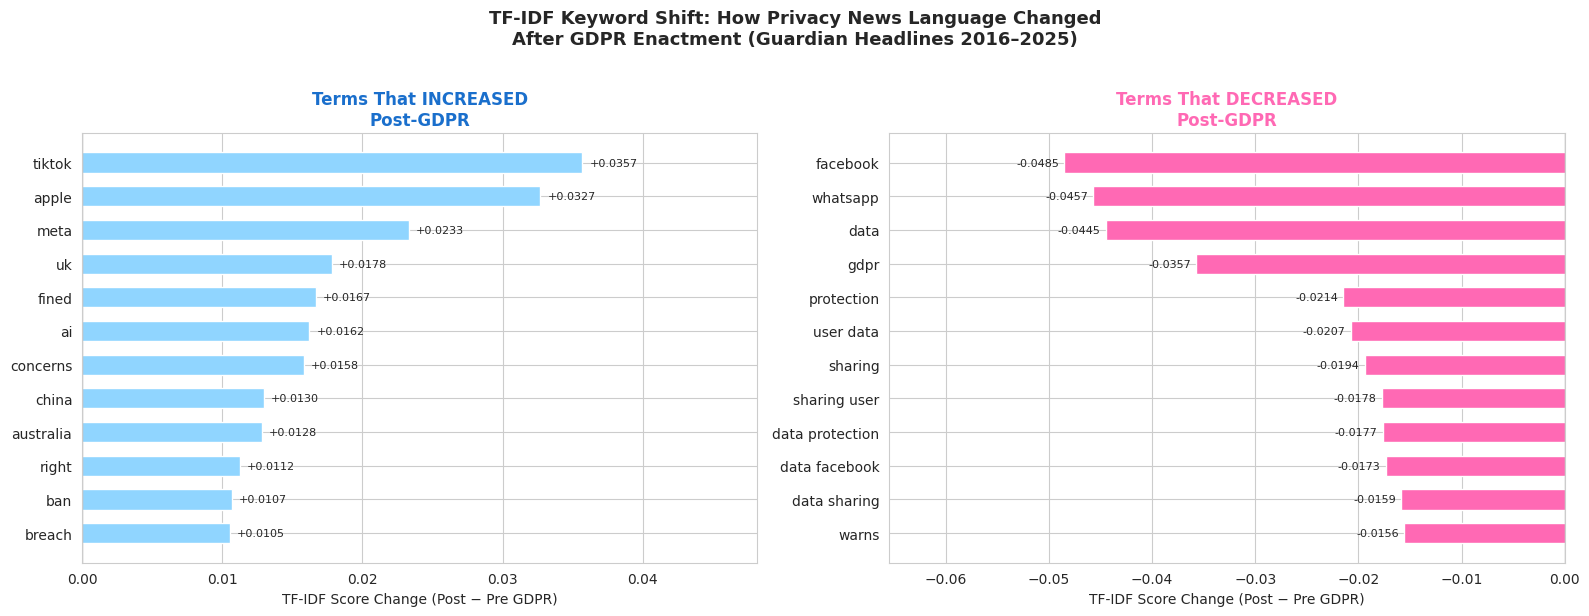

In [59]:
import matplotlib.pyplot as plt

GDPR_COLOR = '#6a0dad'
INC_COLOR  = '#90D5FF'
DEC_COLOR  = '#ff69b4'

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── LEFT — Increased terms ───────────────────────────────────────
bars = axes[0].barh(top_increased['term'],
                    top_increased['shift'],
                    color=INC_COLOR,
                    edgecolor='white', height=0.6)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('TF-IDF Score Change (Post − Pre GDPR)',
                   fontsize=10)
axes[0].set_title('Terms That INCREASED\nPost-GDPR',
                  fontweight='bold', fontsize=12,
                  color='#1a6fcc')
axes[0].invert_yaxis()

# extend x axis slightly to give labels room
xmax_inc = top_increased['shift'].max()
axes[0].set_xlim(0, xmax_inc * 1.35)

for bar, val in zip(bars, top_increased['shift']):
    axes[0].text(val + 0.0005,
                 bar.get_y() + bar.get_height()/2,
                 f'+{val:.4f}', va='center', fontsize=8)

# ── RIGHT — Decreased terms ──────────────────────────────────────
bars2 = axes[1].barh(top_decreased['term'],
                     top_decreased['shift'],
                     color=DEC_COLOR,
                     edgecolor='white', height=0.6)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('TF-IDF Score Change (Post − Pre GDPR)',
                   fontsize=10)
axes[1].set_title('Terms That DECREASED\nPost-GDPR',
                  fontweight='bold', fontsize=12,
                  color='#ff69b4')
axes[1].invert_yaxis()

# extend x axis to give labels room on the left
xmin_dec = top_decreased['shift'].min()
axes[1].set_xlim(xmin_dec * 1.35, 0)

for bar, val in zip(bars2, top_decreased['shift']):
    axes[1].text(val - 0.0005,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:.4f}', va='center',
                 fontsize=8, ha='right')

plt.suptitle(
    'TF-IDF Keyword Shift: How Privacy News Language Changed\n'
    'After GDPR Enactment (Guardian Headlines 2016–2025)',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart5_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()

# **Regression**

In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gdpr_date = pd.Timestamp('2018-05-25')

# build regression features
trends_reg = trends_df.copy()
trends_reg = trends_reg.sort_values('date').reset_index(drop=True)

trends_reg['month_num']       = np.arange(len(trends_reg))
trends_reg['post_gdpr']       = (
    trends_reg['date'] >= gdpr_date).astype(int)
trends_reg['time_after_gdpr'] = (
    trends_reg['month_num'] * trends_reg['post_gdpr'])

X = trends_reg[['month_num', 'post_gdpr', 'time_after_gdpr']]

terms   = ['data privacy', 'GDPR', 'delete Facebook']
results = {}

print("=" * 55)
print("INTERRUPTED TIME SERIES REGRESSION RESULTS")
print("=" * 55)

for term in terms:
    y = trends_reg[term]
    m = LinearRegression()
    m.fit(X, y)
    pred = m.predict(X)
    r2   = r2_score(y, pred)

    results[term] = {
        'r2':          r2,
        'pred':        pred,
        'coef_trend':  m.coef_[0],
        'coef_level':  m.coef_[1],
        'coef_slope':  m.coef_[2],
        'intercept':   m.intercept_
    }

    print(f"\n{term.upper()}")
    print(f"  R²:                    {r2:.3f}")
    print(f"  Monthly trend (pre):   {m.coef_[0]:+.3f}")
    print(f"  Immediate level jump:  {m.coef_[1]:+.3f}")
    print(f"  Slope change post:     {m.coef_[2]:+.3f}")

INTERRUPTED TIME SERIES REGRESSION RESULTS

DATA PRIVACY
  R²:                    0.380
  Monthly trend (pre):   +0.047
  Immediate level jump:  -4.546
  Slope change post:     +0.066

GDPR
  R²:                    0.377
  Monthly trend (pre):   +1.584
  Immediate level jump:  +26.002
  Slope change post:     -1.612

DELETE FACEBOOK
  R²:                    0.820
  Monthly trend (pre):   +0.249
  Immediate level jump:  +0.795
  Slope change post:     -0.452


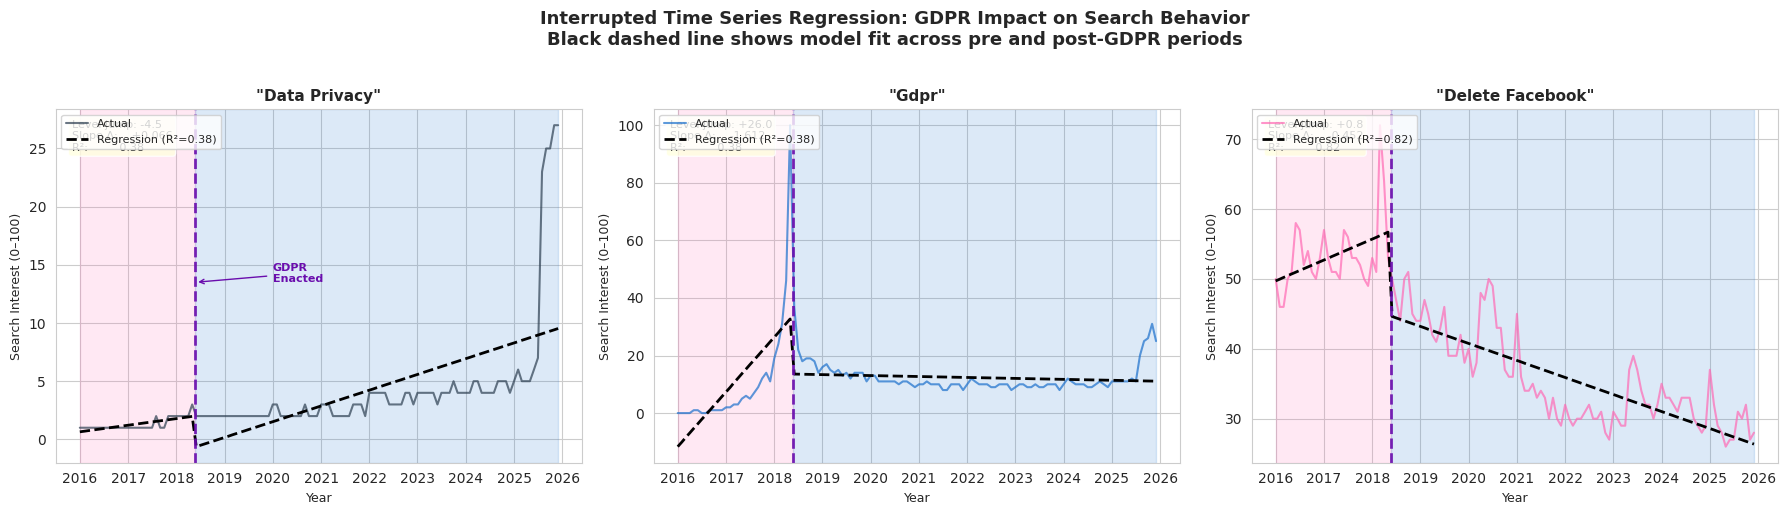

In [73]:
import matplotlib.pyplot as plt
import pandas as pd

GDPR_COLOR = '#6a0dad'
gdpr_date  = pd.Timestamp('2018-05-25')

term_colors = {
    'data privacy':    '#2c3e50',
    'GDPR':            '#1a6fcc',
    'delete Facebook': '#ff69b4'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, term in enumerate(terms):
    ax  = axes[idx]
    res = results[term]

    # shaded regions
    ax.axvspan(trends_reg['date'].min(), gdpr_date,
               alpha=0.15, color='#ff69b4')
    ax.axvspan(gdpr_date, trends_reg['date'].max(),
               alpha=0.15, color='#1a6fcc')

    # actual data
    ax.plot(trends_reg['date'], trends_reg[term],
            color=term_colors[term], linewidth=1.5,
            alpha=0.7, label='Actual')

    # regression line
    ax.plot(trends_reg['date'], res['pred'],
            color='black', linewidth=2,
            linestyle='--',
            label=f"Regression (R²={res['r2']:.2f})")

    # GDPR line
    ax.axvline(gdpr_date, color=GDPR_COLOR,
               linewidth=2, linestyle='--', alpha=0.9)

    # annotation box with coefficients
    ymax = trends_reg[term].max()
    badge = (f"Level jump: {res['coef_level']:+.1f}\n"
             f"Slope Δ:    {res['coef_slope']:+.3f}\n"
             f"R²:         {res['r2']:.2f}")
    ax.text(0.03, 0.97, badge,
            transform=ax.transAxes,
            fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round',
                      facecolor='lightyellow',
                      alpha=0.8))

    # GDPR annotation on first panel only
    if idx == 0:
        ax.annotate('GDPR\nEnacted',
                    xy=(gdpr_date, ymax * 0.5),
                    xytext=(pd.Timestamp('2020-01-01'),
                            ymax * 0.5),
                    fontsize=8, color=GDPR_COLOR,
                    fontweight='bold',
                    arrowprops=dict(arrowstyle='->',
                                    color=GDPR_COLOR))

    ax.set_title(f'"{term.title()}"',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('Search Interest (0–100)', fontsize=9)
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle(
    'Interrupted Time Series Regression: GDPR Impact on Search Behavior\n'
    'Black dashed line shows model fit across pre and post-GDPR periods',
    fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('chart6_regression.png', dpi=150, bbox_inches='tight')
plt.show()

# **Correlation**

In [62]:
from scipy import stats
import pandas as pd

# resample both to monthly
monthly_sent = (df_news.set_index('date')
                .resample('ME')['sentiment']
                .mean().reset_index())
monthly_sent.columns = ['date', 'sentiment']

monthly_trends = (trends_df.set_index('date')
                  .resample('ME')['data privacy']
                  .mean().reset_index())
monthly_trends.columns = ['date', 'data_privacy']

# merge on date
merged = pd.merge(monthly_sent, monthly_trends,
                  on='date', how='inner')

r, p = stats.pearsonr(merged['sentiment'],
                      merged['data_privacy'])
print(f"Correlation: r={r:.3f}, p={p:.4f}")
print("SIGNIFICANT" if p < 0.05 else "NOT SIGNIFICANT")

Correlation: r=nan, p=nan
NOT SIGNIFICANT


In [71]:
from statsmodels.tsa.stattools import grangercausalitytests
import pandas as pd
import numpy as np

# resample both to monthly
monthly_sent = (df_news.set_index('date')
                .resample('ME')['sentiment']
                .mean()
                .reset_index())
monthly_sent.columns = ['date', 'sentiment']

monthly_trends = (trends_df.set_index('date')
                  .resample('ME')[['data privacy',
                                   'GDPR',
                                   'delete Facebook']]
                  .mean()
                  .reset_index())

# merge
merged = pd.merge(monthly_sent, monthly_trends,
                  on='date', how='inner').dropna()

print(f"Monthly observations: {len(merged)}")
print(f"Date range: {merged['date'].min()} to {merged['date'].max()}")

# test up to 3 month lags
max_lag = 3
terms   = ['data privacy', 'GDPR', 'delete Facebook']

for term in terms:
    print(f"\n{'='*55}")
    print(f"Does SENTIMENT Granger-cause '{term}' searches?")
    print(f"{'='*55}")
    data = merged[['sentiment', term]].values
    try:
        grangercausalitytests(data, maxlag=max_lag, verbose=True)
    except Exception as e:
        print(f"Error: {e}")

    print(f"\n{'='*55}")
    print(f"Does '{term}' searches Granger-cause SENTIMENT?")
    print(f"{'='*55}")
    data_rev = merged[[term, 'sentiment']].values
    try:
        grangercausalitytests(data_rev, maxlag=max_lag, verbose=True)
    except Exception as e:
        print(f"Error: {e}")

Monthly observations: 110
Date range: 2016-01-31 00:00:00 to 2025-12-31 00:00:00

Does SENTIMENT Granger-cause 'data privacy' searches?

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=8.5494  , p=0.0042  , df_denom=106, df_num=1
ssr based chi2 test:   chi2=8.7914  , p=0.0030  , df=1
likelihood ratio test: chi2=8.4548  , p=0.0036  , df=1
parameter F test:         F=8.5494  , p=0.0042  , df_denom=106, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=4.3160  , p=0.0158  , df_denom=103, df_num=2
ssr based chi2 test:   chi2=9.0509  , p=0.0108  , df=2
likelihood ratio test: chi2=8.6916  , p=0.0130  , df=2
parameter F test:         F=4.3160  , p=0.0158  , df_denom=103, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=3.9658  , p=0.0102  , df_denom=100, df_num=3
ssr based chi2 test:   chi2=12.7302 , p=0.0053  , df=3
likelihood ratio test: chi2=12.0281 , p=0.0073  , df=3
parameter F test:         F=3.9

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul

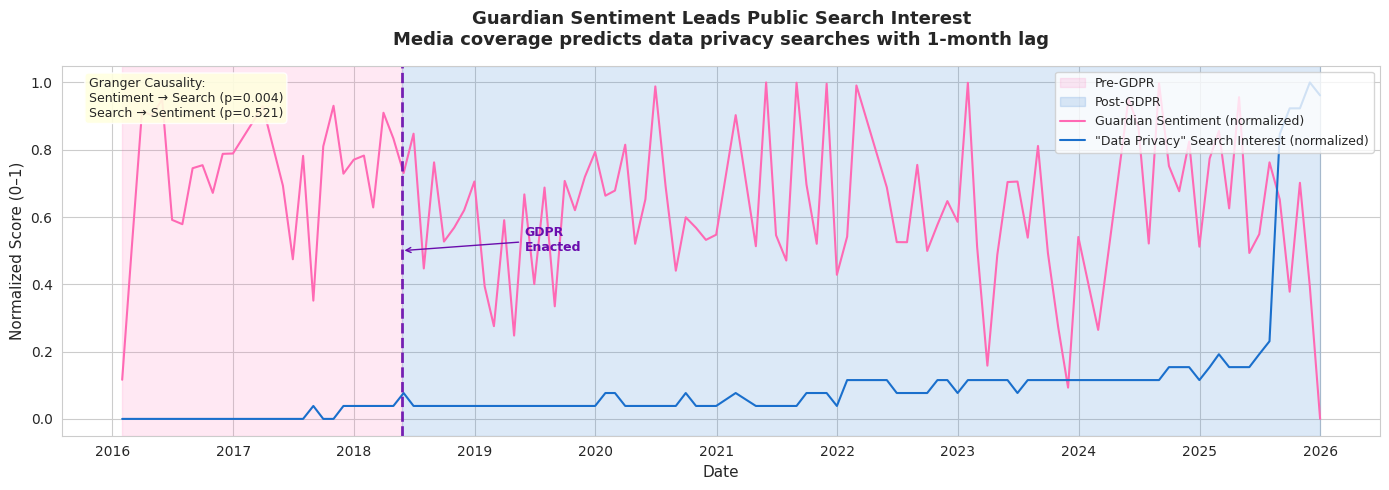

✅ Chart 7 saved!


In [72]:
import matplotlib.pyplot as plt
import pandas as pd

GDPR_COLOR = '#6a0dad'
gdpr_date  = pd.Timestamp('2018-05-25')

fig, ax = plt.subplots(figsize=(14, 5))

# normalize both series to 0-1 for comparison
sent_norm   = ((merged['sentiment'] - merged['sentiment'].min()) /
               (merged['sentiment'].max() - merged['sentiment'].min()))
search_norm = ((merged['data privacy'] - merged['data privacy'].min()) /
               (merged['data privacy'].max() - merged['data privacy'].min()))

# shaded regions
ax.axvspan(merged['date'].min(), gdpr_date,
           alpha=0.15, color='#ff69b4', label='Pre-GDPR')
ax.axvspan(gdpr_date, merged['date'].max(),
           alpha=0.15, color='#1a6fcc', label='Post-GDPR')

# plot both normalized series
ax.plot(merged['date'], sent_norm,
        color='#ff69b4', linewidth=1.5,
        label='Guardian Sentiment (normalized)')
ax.plot(merged['date'], search_norm,
        color='#1a6fcc', linewidth=1.5,
        label='"Data Privacy" Search Interest (normalized)')

# GDPR line
ax.axvline(gdpr_date, color=GDPR_COLOR,
           linewidth=2, linestyle='--', alpha=0.9)

# annotation
ax.annotate('GDPR\nEnacted',
            xy=(gdpr_date, 0.5),
            xytext=(pd.Timestamp('2019-06-01'), 0.5),
            fontsize=9, color=GDPR_COLOR,
            fontweight='bold',
            arrowprops=dict(arrowstyle='->',
                            color=GDPR_COLOR))

# granger result annotation box
ax.text(0.02, 0.97,
        'Granger Causality:\nSentiment → Search (p=0.004)\nSearch → Sentiment (p=0.521)',
        transform=ax.transAxes,
        fontsize=9, verticalalignment='top',
        bbox=dict(boxstyle='round',
                  facecolor='lightyellow',
                  alpha=0.9))

ax.set_title('Guardian Sentiment Leads Public Search Interest\n'
             'Media coverage predicts data privacy searches with 1-month lag',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Normalized Score (0–1)', fontsize=11)
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('chart7_granger.png', dpi=150, bbox_inches='tight')
plt.show()